Welcome to my **Jupytal Notebook Walkthrough**: In this Notebook I aim to, explain **what / why / how to read the output**, and connect each step to the next.

Initally this jupytal nodebook trains all 3 models into disk, but it takes too long in production, hence a python ML production module is built directly in main app.

This notebook now serves as a workthrough of what the ML module in my app entails, and to let you, my future employer. knows i know my shit >:). 

THe Notebook will go through:
| Part | Topic |
|------|--------|
| **1** | Introduction : goal, problem, what shows up |
| **2** | Load data : shape, columns, preview |
| **3** | Cleaning & preparation : missing values, duplicates, types, **targets** |
| **4** | EDA : distributions, correlations |
| **5** | Feature setup : X vs y, chronological split |
| **6** | Modeling : train, metrics, pick a winner |
| **7** | Prediction & inference : probabilities, app payload, **ml_score** math |
| **8** | App integration : how ML mixes with news + technicals |
| **9** | Conclusion : summary, limits, next steps |

## Part 1: Introduction

### Goal

Built an end to end AI trading system that combines machine learning, sentiment analysis, and technical signals into a unified decision engine with backtesting and real time insights. 

And this Notebook shows how i trained machine learning models to predict short term price movements using time series features, sentiment signals, and technical indicators.

### Problem the model is solving

Given the data I have in my data pipline (news, indicators, recent returns, price), how plausible is it that price will satisfy a simple **“up move” rule** in the next **1h / 12h / 24h**?

Each horizon uses a slightly different rule (defined in code). The model outputs a **probability** (and a coarse 0/1 class), then the app turns that into **ml_score** on a −1…+1 scale.

### What this notebook covers

I created this model following a standard ML story:

1) raw table clean table 
2) labels
3) explore (EDA)
4) Split in time
5) train models
6) evaluate
7) predict
8) plug into the app’s final score

### Imports


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix, roc_curve

# Core modules I built for an end to end trading system, from data and ML models to final signal generation and decision logic
from btc_paper.config import Settings
from btc_paper.ml.feature_schema import FEATURE_COLUMNS, FEATURE_VERSION
from btc_paper.ml.train_ml_models import (
    HORIZONS,
    add_targets,
    build_candidate_models,
    chronological_split,
    evaluate_model,
    load_dataset,
    train_all_models,
)
from btc_paper.ml.ml_signal_engine import MLSignalEngine
from btc_paper.signal_engine import combine_scores

warnings.filterwarnings("ignore", category=FutureWarning)
PLOT_TEMPLATE = "plotly_dark"


### repo paths

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists() and (ROOT.parent / "pyproject.toml").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_CSV = ROOT / "data" / "ml_features.csv"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Training CSV found:", DATA_CSV.exists())
print(FEATURE_VERSION, "—", len(FEATURE_COLUMNS), "feature columns")


Repo root: /Users/codergod9000/btc-ai-paper-trading
Training CSV found: True
1.0 — 18 feature columns


---

## Part 2: Load data

### What I’m doing

Bring the dataset into a DataFrame: either the real export (data/ml_features.csv) or a **synthetic** stand-in so the notebook still runs end-to-end.

### Why I’m doing it

Everything downstream assumes one row = **one timestamp**, with the same columns the live bot uses when it builds a feature row.

### Part 2: load into df_raw

**Output to notice:** whether I'm on **real** or **synthetic** data, row count, and a small preview.

In [3]:
# Check if real dataset file exists; fall back to synthetic data if not
USE_REAL = DATA_CSV.exists()


def make_synthetic(n: int = 800, seed: int = 42) -> pd.DataFrame:
    # Generate synthetic dataset with same schema as real data for testing/demo
    rng = np.random.default_rng(seed)
    
    # Simulate BTC-like price series using a random walk
    price = 62000 + np.cumsum(rng.normal(0, 120, size=n))
    
    # Generate hourly timestamps
    ts = pd.date_range("2024-01-01", periods=n, freq="h", tz="UTC")
    
    rows = []
    for i in range(n):
        # Populate feature columns with random values
        row = {c: float(rng.normal(0, 0.12)) for c in FEATURE_COLUMNS}
        
        # Override key indicators with realistic ranges
        row["rsi_1h"] = float(rng.uniform(28, 72))
        row["rsi_4h"] = float(rng.uniform(28, 72))
        
        # Assign simulated price
        row["price_close"] = float(price[i])
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Insert timestamp column as first column
    df.insert(0, "timestamp", ts)
    return df


if USE_REAL:
    # Load actual dataset from CSV
    df_raw = load_dataset(DATA_CSV)
    print("Using file:", DATA_CSV, "—", len(df_raw), "rows")
else:
    # Use synthetic data when real data is not available
    df_raw = make_synthetic(800)
    print("No CSV found — using synthetic demo data.")

Using file: /Users/codergod9000/btc-ai-paper-trading/data/ml_features.csv — 636 rows


### Part 2: shape, columns, dtypes

**What I look for**

1. **Rows** ≈ hours of history in the export.
2. **timestamp** should be unique (I verify duplicates next).
3. **Feature columns** match FEATURE_COLUMNS (18 inputs the model uses).

In [4]:
# Display dataset shape (rows and columns)
display(Markdown(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns"))

# Create summary table of columns, data types, and non-null counts
info = pd.DataFrame(
    {
        "column": df_raw.columns,
        "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
        "non_null": [int(df_raw[c].notna().sum()) for c in df_raw.columns],
    }
)

display(Markdown("Column list and non-null counts"))
display(info)

Shape: 636 rows × 19 columns

Column list and non-null counts

,column,dtype,non_null
0,timestamp,"datetime64[ns, UTC]",636
1,news_score,float64,636
2,technical_score,float64,636
3,final_rule_score,float64,636
4,ema_trend_1h,float64,636
5,ema_trend_4h,float64,636
6,rsi_1h,float64,636
7,rsi_4h,float64,636
8,bollinger_position_1h,float64,636
9,bollinger_position_4h,float64,636


### Part 2: preview rows

Skim a few lines: I want timestamps monotonic, price_close sensible, scores roughly in expected ranges.

In [5]:
display(Markdown("Head"))
display(df_raw.head(5))
display(Markdown("Tail"))
display(df_raw.tail(5))


Head

,timestamp,news_score,technical_score,final_rule_score,ema_trend_1h,ema_trend_4h,rsi_1h,rsi_4h,bollinger_position_1h,bollinger_position_4h,bollinger_width_1h,bollinger_width_4h,macd_score_1h,macd_score_4h,return_1h,return_4h,volume_change_1h,volume_change_4h,price_close
0,2026-03-09 19:04:01+00:00,0.0,0.6,0.24,1.0,0.0,56.714934,50.0,0.672182,0.5,0.056602,0.0,0.5,0.0,-0.002971,0.016678,0.0,0.0,68382.374438
1,2026-03-09 20:03:03+00:00,0.0,0.6,0.24,1.0,0.0,62.627147,50.0,0.814559,0.5,0.053321,0.0,0.5,0.0,0.009227,0.001190,0.0,0.0,69013.321344
2,2026-03-09 21:01:03+00:00,0.0,0.6,0.24,1.0,0.0,62.601029,50.0,0.790186,0.5,0.050902,0.0,0.5,0.0,-0.000026,0.001190,0.0,0.0,69011.531781
3,2026-03-09 22:03:26+00:00,0.0,0.6,0.24,1.0,0.0,62.195756,50.0,0.769161,0.5,0.045770,0.0,0.5,0.0,-0.000376,0.001190,0.0,0.0,68985.567288
4,2026-03-09 23:03:18+00:00,0.0,0.6,0.24,1.0,0.0,56.998708,50.0,0.643024,0.5,0.040622,0.0,0.5,0.0,-0.004922,0.001190,0.0,0.0,68646.004299


Tail

,timestamp,news_score,technical_score,final_rule_score,ema_trend_1h,ema_trend_4h,rsi_1h,rsi_4h,bollinger_position_1h,bollinger_position_4h,bollinger_width_1h,bollinger_width_4h,macd_score_1h,macd_score_4h,return_1h,return_4h,volume_change_1h,volume_change_4h,price_close
631,2026-04-05 02:01:43+00:00,0.0,0.04,0.016,0.0,0.0,47.268684,51.589905,0.329644,0.645809,0.008738,0.027115,-0.5,0.5,-0.001445,-0.000015,0.0,0.0,67097.649997
632,2026-04-05 03:02:17+00:00,0.0,0.04,0.016,0.0,0.0,50.421938,51.589905,0.411562,0.645809,0.008104,0.027115,-0.5,0.5,0.000922,-0.000015,0.0,0.0,67159.488410
633,2026-04-05 04:02:06+00:00,0.0,-0.20,-0.080,0.0,-1.0,48.270067,48.953586,0.301771,0.587311,0.007429,0.022219,-0.5,0.5,-0.000637,-0.002778,0.0,0.0,67116.680741
634,2026-04-05 05:02:50+00:00,0.0,-0.20,-0.080,0.0,-1.0,46.836330,48.953586,0.209886,0.587311,0.006842,0.022219,-0.5,0.5,-0.000425,-0.002778,0.0,0.0,67088.168783
635,2026-04-05 06:01:04+00:00,0.0,-0.12,-0.048,0.0,-1.0,38.633426,48.953586,0.000000,0.587311,0.007802,0.022219,-0.5,0.5,-0.002821,-0.002778,0.0,0.0,66898.910461


### Part 2: what the important columns represent

These are the model inputs (FEATURE_COLUMNS). They are whatever the bot knew at that hour when the row was written.

| Column | Meaning |
|--------|---------|
| news_score | Sentiment / news contribution for that bar |
| technical_score | Rule-based technical score for that bar |
| final_rule_score | Classic combined score (news + technical rule mix used as an ML feature) |
| ema_trend_1h / _4h | Trend feature from EMA structure |
| rsi_1h / rsi_4h | RSI-style momentum |
| bollinger_position_* | Where price sits in the band (position) |
| bollinger_width_* | Band width (volatility proxy) |
| macd_score_* | MACD-derived score |
| return_1h / return_4h | Past returns ending now (not the future target) |
| volume_change_* | Volume change ending now |
| price_close | Spot close used to build future return labels |

---

## Part 3: Data cleaning & preparation

### What I’m doing

1. Measure missing values and duplicate timestamps.
2. Coerce feature columns to numeric (bad strings → NaN).
3. Drop duplicate timestamps (keep the last row).
4. Create targets by looking forward in price_close.

### Why I’m doing it

1. Training silently breaks if duplicates shift “the future” in weird ways.
2. Tree/linear pipelines here use **imputation inside sklearn Pipelines** for missing *features* (median). Rows without a target are dropped for training.
3. Targets must be defined **without peeking** from the future into features: I only use future prices to label the past row.

### Part 3a: missing values

**How I read it:** large counts on many columns → weak or inconsistent export; a few missing values are normal in real market data.

In [6]:
# Check missing values for key columns (features + timestamp + price)
feature_and_key = [c for c in df_raw.columns if c in FEATURE_COLUMNS or c in ("timestamp", "price_close")]

# Count missing values per column and sort descending
missing = df_raw[feature_and_key].isna().sum().sort_values(ascending=False)

# Format into a readable table
missing_tbl = missing.reset_index()
missing_tbl.columns = ["column", "missing_count"]

# Add percentage of missing values
missing_tbl["pct"] = (missing_tbl["missing_count"] / len(df_raw)).map(lambda x: f"{x:.1%}")

# Display only columns with missing values (or a small sample if none)
display(
    missing_tbl.query("missing_count > 0").head(25)
    if missing_tbl["missing_count"].any()
    else missing_tbl.head(5)
)

print("Total rows:", len(df_raw))

,column,missing_count,pct
0,timestamp,0,0.0%
1,bollinger_width_1h,0,0.0%
2,volume_change_4h,0,0.0%
3,volume_change_1h,0,0.0%
4,return_4h,0,0.0%


Total rows: 636


### Part 3b: duplicate timestamps

**What I want:** 0 duplicates. If not, I keep the **last** row per timestamp.

In [7]:
dup_ts = int(df_raw["timestamp"].duplicated().sum())
print("Duplicate timestamps:", dup_ts)

df_clean = df_raw.copy()
if dup_ts:
    before = len(df_clean)
    df_clean = df_clean.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last")
    print("Dropped", before - len(df_clean), "duplicate timestamp rows")

# Coerce model inputs to numeric (invalid → NaN); training pipeline will impute medians.
for c in FEATURE_COLUMNS:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

print("Rows after cleaning:", len(df_clean))


Duplicate timestamps: 0
Rows after cleaning: 636


### Part 3c: creating targets (the **y** variables)

For each row at time t, I compare today’s price_close to price_close shifted into the future by N bars (hours in this dataset).

For each configured horizon:

1. Compute future return = \((P_{t+N} - P_t) / P_t\)
2. Set target = 1 if that return is above a threshold, else **0**
3. Last rows have no future, so targets are missing, which is expected.

| Target column | Lookahead | “Up” means |
|---------------|-----------|------------|
| target_up_1h | 1 bar | future return **> 0%** (any up move) |
| target_up_12h | 12 bars | future return **> 0.5%** |
| target_up_24h | 24 bars | future return **> 1%** |

**Why different thresholds?** Longer horizons aim for slightly larger moves so the label is not pure noise.

In [8]:
df = add_targets(df_clean, HORIZONS)

# Show the last rows targets become NaN when future price is missing.
show_cols = ["timestamp", "price_close"] + [h.name for h in HORIZONS]
display(df[show_cols].tail(8))


,timestamp,price_close,target_up_1h,target_up_12h,target_up_24h
628,2026-04-04 23:02:32+00:00,67387.661682,0,0,0
629,2026-04-05 00:02:09+00:00,67305.532706,0,0,0
630,2026-04-05 01:01:47+00:00,67194.731024,0,0,0
631,2026-04-05 02:01:43+00:00,67097.649997,1,0,0
632,2026-04-05 03:02:17+00:00,67159.488410,0,0,0
633,2026-04-05 04:02:06+00:00,67116.680741,0,0,0
634,2026-04-05 05:02:50+00:00,67088.168783,0,0,0
635,2026-04-05 06:01:04+00:00,66898.910461,0,0,0


### Part 3d: target balance (all horizons)

**How I read it:** if 'up' is **extremely rare or extremely common**, metrics like accuracy can look misleading which is why I also use ROC AUC and look at confusion matrices later.

,Target,P(up = 1),labeled rows
0,target_up_1h,49.1%,636
1,target_up_12h,33.3%,636
2,target_up_24h,27.0%,636


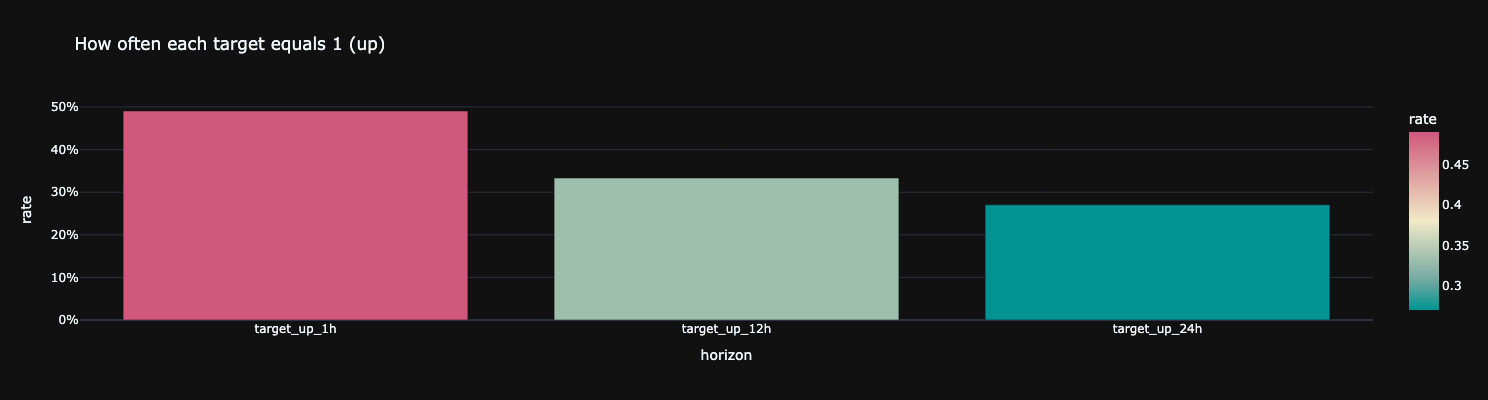

In [9]:
# Evaluate class balance across prediction horizons to check for label skew

balance_rows = []
for h in HORIZONS:
    s = df[h.name].dropna()
    balance_rows.append(
        {
            "Target": h.name,
            "P(up = 1)": float(s.mean()) if len(s) else 0.0,
            "labeled rows": int(len(s)),
        }
    )

bal = pd.DataFrame(balance_rows)
bal["P(up = 1)"] = bal["P(up = 1)"].map(lambda x: f"{x:.1%}")
display(bal)


# Visualize positive label rate for each horizon
rates = []
for h in HORIZONS:
    s = df[h.name].dropna()
    rates.append({"horizon": h.name, "rate": float(s.mean()) if len(s) else 0.0})

fig = px.bar(
    pd.DataFrame(rates),
    x="horizon",
    y="rate",
    title="How often each target equals 1 (up)",
    template=PLOT_TEMPLATE,
    color="rate",
    color_continuous_scale="Tealrose",
)

fig.update_layout(showlegend=False, yaxis_tickformat=".0%", height=400)
fig.show()

---

## Part 4: Exploratory data analysis (EDA)

### What I’m doing

I treat this like a mini investigation:

1. Plot distributions for a few interpretable inputs.
2. Measure feature vs target correlation for the 12h target (a quick linear hint; not the full story).
3. Plot a feature correlation heatmap to spot redundancy.

### Why I’m doing it

I want to catch obvious issues **before** trusting metrics: broken columns, stale features, absurd correlations, or targets that are impossible to predict from inputs.

### What the two charts tells me

1. **Histograms:** skew, outliers, weird spikes at one value.
2. **Heatmap:** very bright red/blue pairs = features move together = multicollinearity.

### Part 4: pick one target for deep EDA

I standardize on **target_up_12h** for plots in this section (the same target I use for the model bake-off in Part 6).

In [10]:
EDA_TARGET = "target_up_12h"
eda_df = df.dropna(subset=[EDA_TARGET]).copy()
print("Rows with a 12h label:", len(eda_df))

Rows with a 12h label: 636


### Part 4: feature distributions (sample)

**What I look for:** do shapes look plausible? Do I see a single spike at zero everywhere (can happen with synthetic data)?

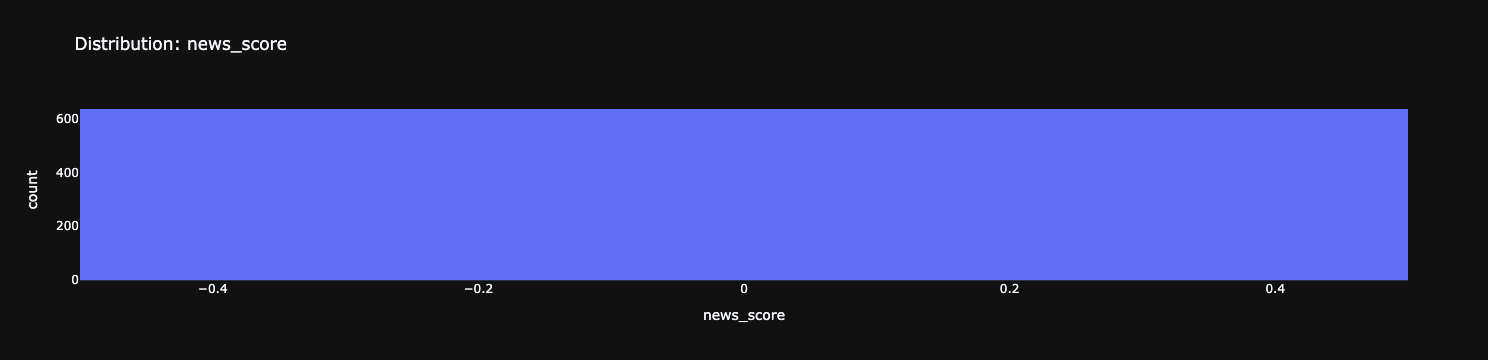

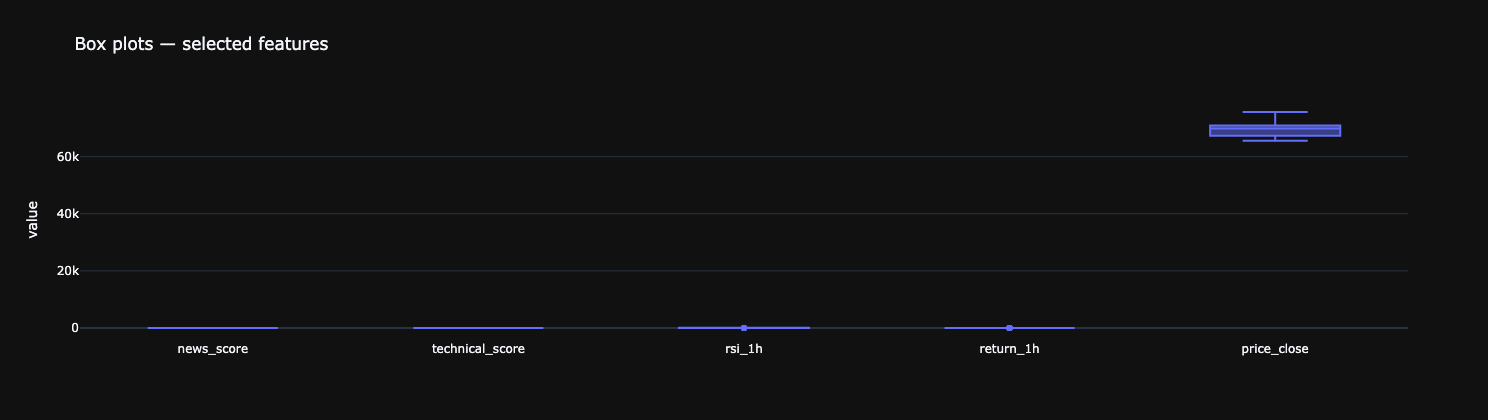

In [11]:
# Plot distributions and basic stats for selected features (EDA)

plot_cols = [
    "news_score",
    "technical_score",
    "rsi_1h",
    "return_1h",
    "price_close",
]

# Keep only columns that exist in the dataset
plot_cols = [c for c in plot_cols if c in eda_df.columns]

# Histogram for the first feature
fig = px.histogram(
    eda_df,
    x=plot_cols[0],
    nbins=40,
    title=f"Distribution: {plot_cols[0]}",
    template=PLOT_TEMPLATE,
)
fig.update_layout(height=360)
fig.show()

# Box plots for multiple features to compare spread and outliers
if len(plot_cols) > 1:
    melt = eda_df[plot_cols].melt(var_name="feature", value_name="value")
    fig2 = px.box(
        melt,
        x="feature",
        y="value",
        title="Box plots — selected features",
        template=PLOT_TEMPLATE,
    )
    fig2.update_layout(height=420, xaxis_title="")
    fig2.show()

### Part 4a: correlation investigation

**Feature vs target (Pearson with 0/1 label):** a rough “linear association” screen.

**Feature vs feature heatmap:** highlights redundant pairs (e.g. multiple momentum proxies tracking the same idea).

**What would worry me?** A feature perfectly correlated with the target can mean **leakage** where targets come only from future price, so inputs must not include future returns.

/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/pyth

**Correlation with target_up_12h (Pearson)**

,feature,corr_with_12h_target
6,rsi_4h,-0.109
10,bollinger_width_4h,-0.105
17,price_close,-0.079
7,bollinger_position_1h,-0.068
5,rsi_1h,-0.035
3,ema_trend_1h,-0.034
8,bollinger_position_4h,-0.030
12,macd_score_4h,+0.026
4,ema_trend_4h,-0.021
1,technical_score,+0.012


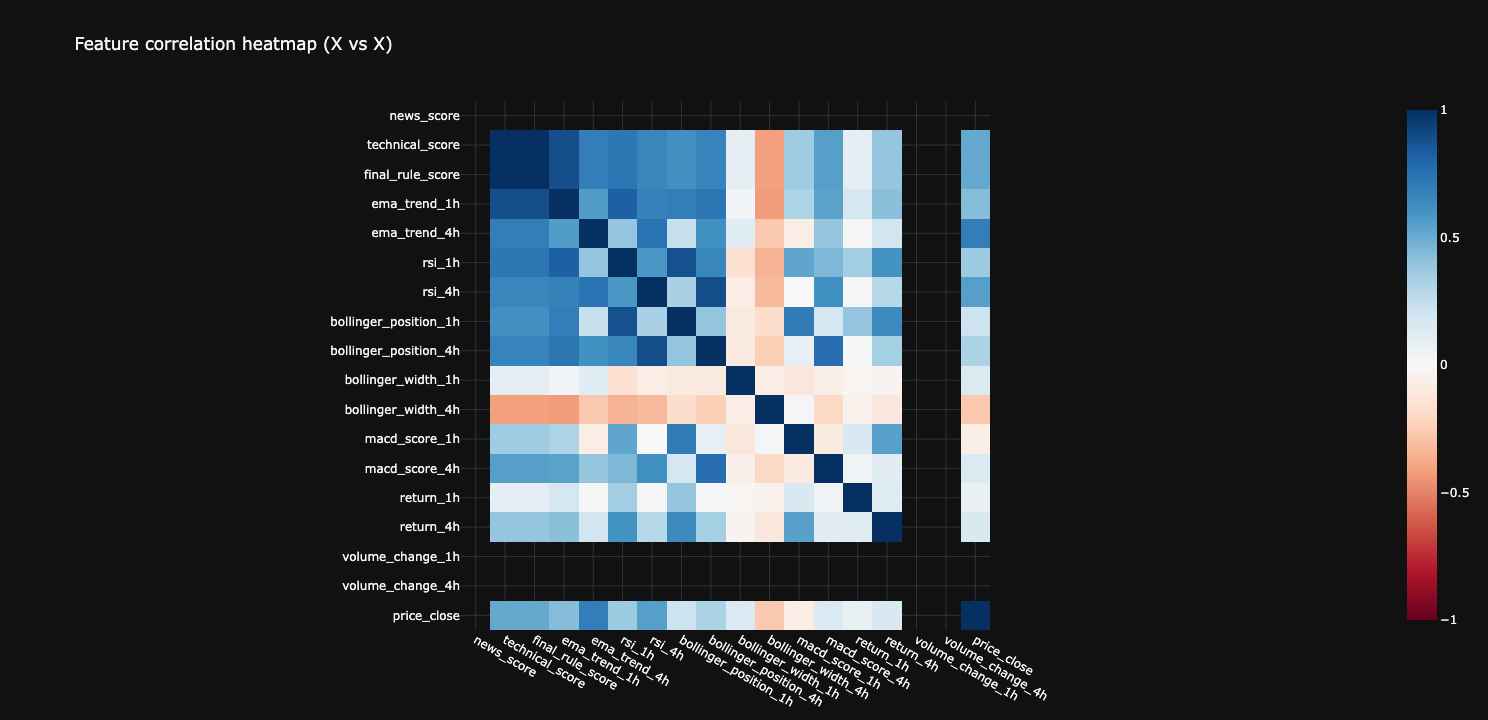

In [12]:
# Convert all feature columns to numeric (force invalid values to NaN)
for c in FEATURE_COLUMNS:
    eda_df[c] = pd.to_numeric(eda_df[c], errors="coerce")

# Compute correlation between each feature and the target (12h direction)
corr_rows = []
for c in FEATURE_COLUMNS:
    s = eda_df[[c, EDA_TARGET]].dropna()  # drop rows with missing values
    if len(s) < 10:  # skip if too little data
        continue
    corr_rows.append({"feature": c, "corr_with_12h_target": float(s[c].corr(s[EDA_TARGET]))})

# Rank features by strength of correlation (absolute value)
corr_df = pd.DataFrame(corr_rows).sort_values("corr_with_12h_target", key=abs, ascending=False)

# Display correlation results
display(Markdown("**Correlation with target_up_12h (Pearson)**"))
display(corr_df.style.format({"corr_with_12h_target": "{:+.3f}"}))

# Compute feature-to-feature correlation matrix
Xnum = eda_df[FEATURE_COLUMNS].astype(float)
x_corr = Xnum.corr()

# Plot heatmap to identify highly correlated (possibly redundant) features
fig = px.imshow(
    x_corr,
    x=x_corr.columns,
    y=x_corr.index,
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
    title="Feature correlation heatmap (X vs X)",
)
fig.update_layout(template=PLOT_TEMPLATE, height=720)
fig.show()

### Part 4b: plain-language observations (fill in after running)

After running on the real CSV, I jot down 2:4 bullets like:

1. **Class balance:** is target_up_12h roughly balanced, or heavily skewed?
2. **Stability:** do news_score / technical_score vary, or are they flat (data issue)?
3. **Correlation surprises:** anything much stronger than I expected?
4. **Data trust:** duplicates / missingness acceptable?

---

## Part 5: Feature setup (X, y, and the time split)

### What I’m doing

1. **X (inputs):** the 18 columns in FEATURE_COLUMNS (fixed order for training + live inference).
2. **y (label):** for modeling I focus on target_up_12h in Parts 6:7 (the app still trains three horizon models when the CLI runs).
3. **Split:** first 80% of time and then train, last 20% and then test.

### Why these features

They mirror what the running bot can compute from stored candles + the same sentiment/technical pipeline: news, technicals, indicator summaries, recent returns/volume, and spot price.

### Why chronological split (not random)

Random train/test would let the model see **future** market regimes while “predicting” the past : metrics would look **optimistic** and lie about real performance.

In [13]:
display(Markdown("Input feature list (X) — order is part of the contract"))
display(pd.DataFrame({"feature": FEATURE_COLUMNS}))

train_df, test_df = chronological_split(df, train_ratio=0.8)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train time range:", train_df["timestamp"].iloc[0], "→", train_df["timestamp"].iloc[-1])
print("Test time range: ", test_df["timestamp"].iloc[0], "→", test_df["timestamp"].iloc[-1])


Input feature list (X) — order is part of the contract

,feature
0,news_score
1,technical_score
2,final_rule_score
3,ema_trend_1h
4,ema_trend_4h
5,rsi_1h
6,rsi_4h
7,bollinger_position_1h
8,bollinger_position_4h
9,bollinger_width_1h


Train rows: 508 | Test rows: 128
Train time range: 2026-03-09 19:04:01+00:00 → 2026-03-30 22:01:55+00:00
Test time range:  2026-03-30 23:02:34+00:00 → 2026-04-05 06:01:04+00:00


---

## Part 6: Modeling & training

### What I’m doing

Fit a few **classification** models that output **P(up)** for target_up_12h, then compare them on the **held-out future** test set.

### Models (simple descriptions)

1. **Logistic regression:** a linear baseline; fast, interpretable-ish, often surprisingly strong.
2. **Random forest:** many decision trees vote; handles nonlinear patterns, gives **feature importance** if it wins.
3. **XGBoost**: boosted trees, strong default for tabular data.

### Metrics (how to read them)

1. **ROC AUC:** how well the model **ranks** positives above negatives (0.5 ≈ coin flip).
2. **Accuracy / precision / recall / F1:** depend heavily on class balance : read them alongside the confusion matrix.
3. **Predicted positive rate vs actual:** catches a model that always guesses “up”.

### Part 6a: train & compare (12h target)

**What I look for:** which model has the best ROC AUC on the **test** slice, and whether ROC curves hug the diagonal (weak model).

/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/codergod9000/btc-ai-paper-trading/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

**Test-set metrics (sorted by ROC AUC)**

,model,roc_auc,accuracy,precision,recall,f1,positive_rate_predicted,positive_rate_actual
2,xgboost,0.6108,0.7578,0.5455,0.3636,0.4364,0.1719,0.2578
1,random_forest,0.5668,0.7422,0.5000,0.2424,0.3265,0.1250,0.2578
0,logistic_regression,0.5250,0.4922,0.2647,0.5455,0.3564,0.5312,0.2578


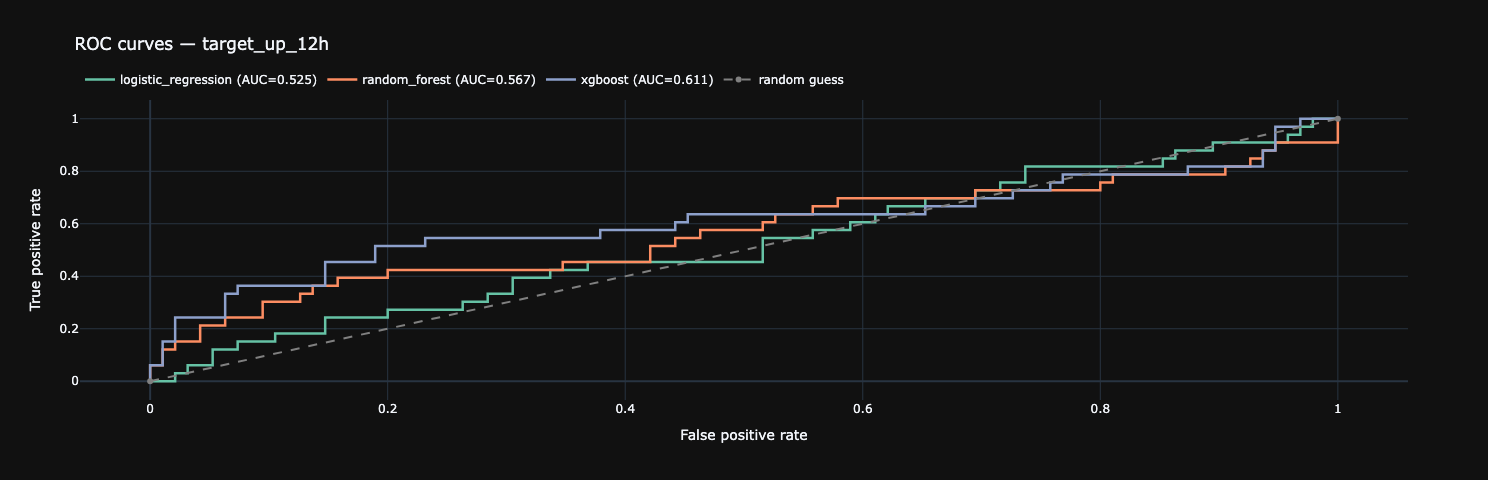

Winner on this split (by ROC AUC): xgboost


In [14]:
# Define target column and feature set
TARGET = "target_up_12h"
feature_cols = FEATURE_COLUMNS.copy()

# Drop rows with missing target values
tr = train_df.dropna(subset=[TARGET])
te = test_df.dropna(subset=[TARGET])

# Split into features (X) and labels (y)
X_train, y_train = tr[feature_cols], tr[TARGET].astype(int)
X_test, y_test = te[feature_cols], te[TARGET].astype(int)

# Build candidate models to compare
candidates = build_candidate_models()

metrics_rows = []
roc_fig = go.Figure()
colors = px.colors.qualitative.Set2

# Train and evaluate each model
for i, (name, pipe) in enumerate(candidates.items()):
    pipe.fit(X_train, y_train)  # train model
    
    prob = pipe.predict_proba(X_test)[:, 1]  # predicted probability of class 1
    
    m = evaluate_model(pipe, X_test, y_test)  # compute evaluation metrics
    metrics_rows.append({"model": name, **m})
    
    # Compute ROC curve (skip if invalid)
    try:
        fpr, tpr, _ = roc_curve(y_test, prob)
    except ValueError:
        continue
    
    # Add ROC curve for this model
    roc_fig.add_trace(
        go.Scatter(
            x=fpr,
            y=tpr,
            name=f"{name} (AUC={m['roc_auc']:.3f})",
            line=dict(width=2.5, color=colors[i % len(colors)]),
        )
    )

# Rank models by ROC AUC
metrics_df = pd.DataFrame(metrics_rows).sort_values("roc_auc", ascending=False, na_position="last")

# Display evaluation results
display(Markdown("**Test-set metrics (sorted by ROC AUC)**"))
display(metrics_df.round(4))

# Add baseline (random guessing) line to ROC plot
roc_fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], name="random guess", line=dict(dash="dash", color="gray")))

# Finalize ROC plot layout
roc_fig.update_layout(
    title="ROC curves — " + TARGET,
    template=PLOT_TEMPLATE,
    xaxis_title="False positive rate",
    yaxis_title="True positive rate",
    height=480,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
roc_fig.show()

# Print best performing model on this split
best_name = metrics_df.iloc[0]["model"]
print("Winner on this split (by ROC AUC):", best_name)

### Part 6b: confusion matrix (winner)

**How I read it:** diagonal counts are correct; off-diagonal are errors. Compare to the **baseline** I get by always predicting the majority class.

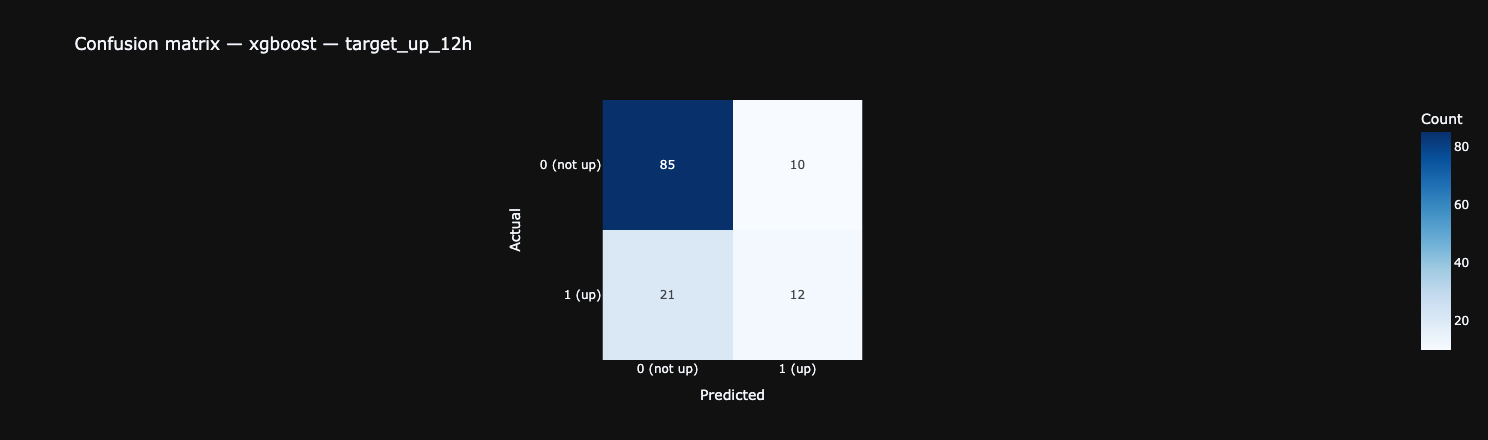

In [15]:
best_pipe = candidates[best_name]
best_pipe.fit(X_train, y_train)
y_prob = best_pipe.predict_proba(X_test)[:, 1]
y_hat = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_hat)

fig_cm = px.imshow(
    cm,
    text_auto=True,
    color_continuous_scale="Blues",
    labels=dict(x="Predicted", y="Actual", color="Count"),
    x=["0 (not up)", "1 (up)"],
    y=["0 (not up)", "1 (up)"],
    title="Confusion matrix — " + best_name + " — " + TARGET,
)
fig_cm.update_layout(template=PLOT_TEMPLATE, width=520, height=440)
fig_cm.show()


### Part 6c: which features mattered? (tree winners only)

If the winner is **random forest** / boosting, you get feature_importances_. If **logistic regression** wins, this cell will note that : use coefficients or SHAP in a follow-up project if deeper interpretability is needed.

**Caveat:** importance ≠ causation.

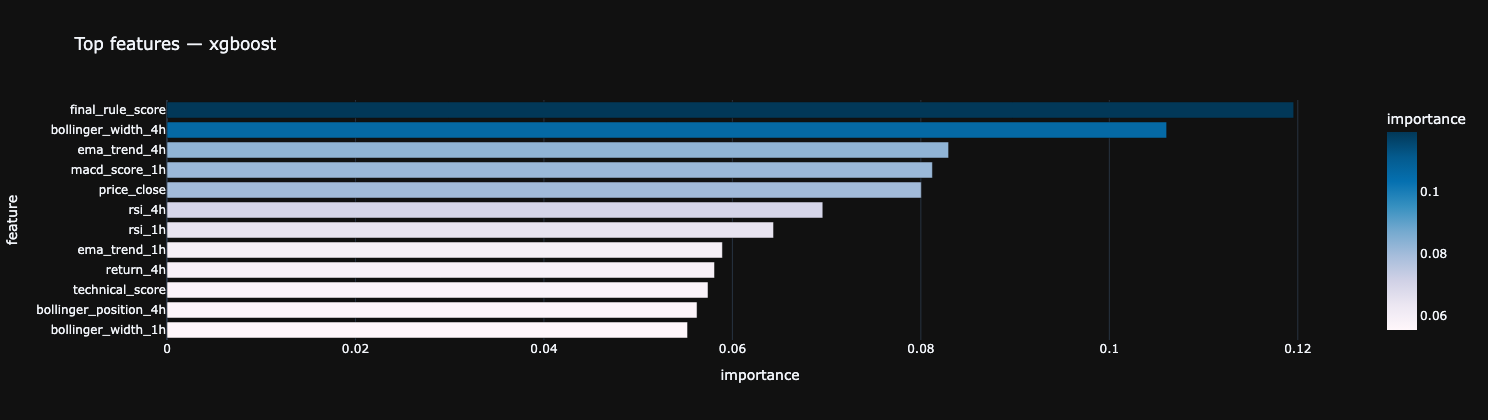

In [16]:
def plot_importance(pipe, title: str, top_k: int = 12):
    step = pipe.named_steps.get("model")
    if step is None or not hasattr(step, "feature_importances_"):
        print("No feature_importances_ for this model type.")
        return
    imp = step.feature_importances_
    idx = np.argsort(imp)[::-1][:top_k]
    sub = pd.DataFrame({"feature": [feature_cols[j] for j in idx], "importance": imp[idx]})
    fig = px.bar(
        sub.iloc[::-1],
        x="importance",
        y="feature",
        orientation="h",
        title=title,
        template=PLOT_TEMPLATE,
        color="importance",
        color_continuous_scale="PuBu",
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()


plot_importance(best_pipe, "Top features — " + best_name)


---

## Part 7: Prediction & inference

### What I’m doing

1. Show **test-row predictions** from the Part 6 winner: **probability** and **thresholded class**.
2. Explain how the **live app** builds **ml_prob**, **ml_score**, and **ml_bias** from **three** horizon models.
3. If models/model_metadata.json exists, run the real MLSignalEngine on a sample row.

### Why two stories?

1. Part 6 trains **one** horizon inside the notebook for teaching.
2. Production trains **three** models (1h / 12h / 24h) and blends them.

### Key formulas (from my module, MLSignalEngine.predict)

Let \(p_1, p_{12}, p_{24}\) be the three probabilities. Default horizon weights are **0.2 / 0.4 / 0.4**:

\[
ml\_prob = w_1 p_1 + w_{12} p_{12} + w_{24} p_{24}
\]

\[
ml\_score = 2 \cdot (ml\_prob - 0.5) \in [-1, 1]
\]

**Bias labels:** bullish if ml_score > 0.2, bearish if < -0.2, else neutral.

### Part 7a: inspect a slice of test predictions (12h model only)

In [17]:
preview_n = min(12, len(X_test))
pred_tbl = pd.DataFrame(
    {
        "actual_up": y_test.iloc[:preview_n].values,
        "P(up)": y_prob[:preview_n],
        "predicted_class": y_hat[:preview_n],
    }
)
display(Markdown(f"**First {preview_n} test rows — {best_name}**"))
display(pred_tbl.style.format({"P(up)": "{:.3f}"}))


**First 12 test rows — xgboost**

,actual_up,P(up),predicted_class
0,0,0.223,0
1,0,0.585,1
2,0,0.241,0
3,0,0.183,0
4,0,0.022,0
5,0,0.175,0
6,0,0.132,0
7,0,0.128,0
8,0,0.160,0
9,1,0.155,0


### Part 7b: live engine output (three horizons)

If trained artifacts exist under models/, this matches what the pipeline stores in SQLite (breakdown["ml"]).

If not, train with:

btc-paper-train-ml --csv data/ml_features.csv --output-dir models

Then re-run this cell.

In [18]:
# Format and display model inference results in a readable way
def show_inference_result(payload: dict) -> None:
    hp = payload.get("horizon_predictions") or {}
    rows = []
    for key, v in hp.items():
        if not isinstance(v, dict):
            continue
        short = key.replace("target_up_", "")
        p = float(v.get("prob_up", 0))
        cls = int(v.get("predicted_class", 0))
        rows.append(
            {
                "Horizon": short,
                "P(up)": f"{p:.1%}",
                "predicted_class (≥50% → 1)": cls,
                "Saved model type": v.get("model_name", "—"),
            }
        )
    
    # Display per-horizon predictions
    display(Markdown("**Per horizon**"))
    display(pd.DataFrame(rows))

    # Extract blended ML outputs (used by the rest of the system)
    mp = float(payload.get("ml_prob", 0))
    ms = float(payload.get("ml_score", 0))
    bias = str(payload.get("ml_bias", "—"))
    
    display(Markdown("**Blended ML fields (what the rest of the bot reads)**"))
    display(
        pd.DataFrame(
            [
                {
                    "ml_prob (0–1)": f"{mp:.3f}",
                    "ml_score (−1…+1)": f"{ms:+.3f}",
                    "ml_bias": bias,
                    "feature_version": payload.get("feature_version", "—"),
                    "trained_at (metadata)": payload.get("training_run_at", "—"),
                }
            ]
        )
    )


# Load model metadata and prepare a sample input row for inference
meta_path = MODELS_DIR / "model_metadata.json"
sample_row = df[FEATURE_COLUMNS].iloc[-5].to_dict()

# Run inference only if trained models exist
if meta_path.exists():
    settings = Settings()
    engine = MLSignalEngine(MODELS_DIR)  # load trained models
    
    # Generate predictions using weighted horizons
    payload = engine.predict(
        sample_row,
        w_1h=settings.ml_horizon_weight_1h,
        w_12h=settings.ml_horizon_weight_12h,
        w_24h=settings.ml_horizon_weight_24h,
    )
    
    # Display model outputs
    show_inference_result(payload)

    # Extract probabilities for each horizon
    hp = payload.get("horizon_predictions") or {}
    p1 = float(hp.get("target_up_1h", {}).get("prob_up", 0.5))
    p12 = float(hp.get("target_up_12h", {}).get("prob_up", 0.5))
    p24 = float(hp.get("target_up_24h", {}).get("prob_up", 0.5))
    
    # Get weights used for blending
    w1, w12, w24 = settings.ml_horizon_weight_1h, settings.ml_horizon_weight_12h, settings.ml_horizon_weight_24h
    
    # Manually recompute blended probability and score (sanity check)
    manual_prob = w1 * p1 + w12 * p12 + w24 * p24
    manual_score = 2.0 * (manual_prob - 0.5)
    
    # Verify computed values match model output
    display(Markdown("**Checksum — recompute ml_prob / ml_score from printed horizons**"))
    display(
        pd.DataFrame(
            [
                {
                    "w1*p1 + w12*p12 + w24*p24": f"{manual_prob:.4f}",
                    "2*(ml_prob-0.5)": f"{manual_score:+.4f}",
                    "matches payload?": abs(manual_prob - float(payload.get("ml_prob", 0))) < 1e-6,
                }
            ]
        )
    )
else:
    # Skip if models are not trained yet
    print("No models/ metadata yet — skipping live engine demo.")

**Per horizon**

,Horizon,P(up),predicted_class (≥50% → 1),Saved model type
0,1h,50.3%,1,random_forest
1,12h,78.9%,1,xgboost
2,24h,87.4%,1,logistic_regression


**Blended ML fields (what the rest of the bot reads)**

,ml_prob (0–1),ml_score (−1…+1),ml_bias,feature_version,trained_at (metadata)
0,0.766,+0.532,bullish,1.0,2026-04-06T08:40:17+00:00


**Checksum — recompute ml_prob / ml_score from printed horizons**

,w1*p1 + w12*p12 + w24*p24,2*(ml_prob-0.5),matches payload?
0,0.7658,+0.5317,True


---

## Part 8: Final integration into the app

### What happens in production (combine_scores)

When ML artifacts load successfully, the bot blends **three scores** on the same −1…+1-ish scale:

\[
final\_score = \frac{w_n \cdot news + w_t \cdot technical + w_m \cdot ml\_score}{w_n + w_t + w_m}
\]

**Defaults** (from Settings, overridable via env):

1. \(w_n = 0.3\) (SIGNAL_NEWS_WEIGHT)
2. \(w_t = 0.3\) (SIGNAL_TECH_WEIGHT)
3. \(w_m = 0.4\) (SIGNAL_ML_WEIGHT)

If ML is **off** or models are **missing**, weights fall back to legacy **0.6 / 0.4** news vs technical (which is renormalized the same way).

### Conflict dampening (good to mention in interviews)

If sentiment, technicals, and ML strongly disagree, the pipeline can dampen the unified score by **signal_conflict_dampen** (default **0.7**). See signal_engine.combine_scores.

### Where this notebook connects

| Stage | Notebook | App |
|------|----------|-----|
| Row of inputs | df / sample_row | build_live_ml_feature_row |
| Training | optional train_all_models cell | btc-paper-train-ml |
| ML output | MLSignalEngine.predict | try_ml_predict to stored breakdown |
| Final trade idea | combine_scores | pipeline + SQLite + Streamlit |

### Part 8: numeric example of the final blend

Plug in **example** scores to see how weights move the needle. Replace with real numbers from a logged signal anytime.

In [19]:
settings = Settings()
news_score = 0.25
technical_score = -0.10
ml_score = 0.40

res = combine_scores(
    settings,
    news_score=news_score,
    technical_score=technical_score,
    ml_score=ml_score,
    news_summary="example",
    technical_summary="example",
    ml_active=True,
    ml_payload={"ml_prob": 0.62, "ml_bias": "bullish"},
)

wn, wt, wm = settings.news_weight, settings.technical_weight, settings.ml_weight
denom = wn + wt + wm
manual_final = (wn * news_score + wt * technical_score + wm * ml_score) / denom

display(
    pd.DataFrame(
        [
            {
                "news_score": news_score,
                "technical_score": technical_score,
                "ml_score": ml_score,
                "weights (n/t/m)": f"{wn}/{wt}/{wm}",
                "manual final (should match)": manual_final,
                "combine_scores final": res.final_score,
                "action": res.action,
                "conflict_dampened": res.breakdown.get("conflict_dampened"),
            }
        ]
    )
)
print(res.reason)


,news_score,technical_score,ml_score,weights (n/t/m),manual final (should match),combine_scores final,action,conflict_dampened
0,0.25,-0.1,0.4,0.3/0.3/0.4,0.205,0.205,HOLD,False


Sentiment supportive (+0.25) Technicals roughly neutral (-0.10) ML bias **bullish** (blended up-prob 0.62, score +0.40 on −1…+1). Unified score **+0.205** → **HOLD**. Context — News: example | Technicals: example


### save all three horizon models (Will skip this because it takes too long to run for deployed app, integrated ML model directly into app via python)

In [20]:
# csv_in = DATA_CSV if USE_REAL else None
# if csv_in is None:
#     tmp = ROOT / "data" / "_notebook_export.csv"
#     df.to_csv(tmp, index=False)
#     csv_in = tmp
# train_all_models(csv_in, output_dir=MODELS_DIR, train_ratio=0.8)
# print("Saved under", MODELS_DIR)

print("Skipped saving. Uncomment in this cell to train all horizons to disk.")


Skipped saving. Uncomment in this cell to train all horizons to disk.


## Part 9: Conclusion

### What I built

I started from a **time-ordered table** of market + signal features, cleaned it, defined **forward-looking** targets, explored basic patterns, split **chronologically**, trained several classifiers, and inspected predictions as **probabilities**.

I then connected that to the **real app**: three horizon models → **ml_prob / ml_score**, and finally **combine_scores** to mix ML with **news** and **technicals**.

### What this shows

1. **Targets are engineered**, not magically present in the CSV.
2. **Time splits** matter; random splits flatter tabular market models.
3. **ROC AUC** is usually the first ranking metric to trust for imbalanced “up/down” tasks, but it still does not guarantee trading profit.
4. **Production inference** can differ from a single-horizon notebook bake-off : here the app blends **1h / 12h / 24h**.

### Limitations and Future Works

1. Labels are **simple return thresholds**, not transaction costs, slippage, or position sizing.
2. Features include **price_close**; tree models can exploit it : be careful interpreting “importance” as tradable insight.
3. Synthetic data is only for UI/demo; **real CSV** is required for credible conclusions.

### Suggested next improvements

1. Walk-forward validation (rolling retrain windows).
2. Calibration curves / Brier score for probabilities.
3. Separate reporting for **regime shifts** (bull vs bear).
4. Feature ablation study (remove groups of features and watch AUC).